# 03 - Informe final con curvas ROC

Este informe recoge la decisión final del modelo usando la comparación de curvas ROC y la métrica principal de validación, F1.

La elección del modelo ganador se ha basado en el equilibrio entre sensibilidad y precisión, evaluado sobre la partición temporal de validación.

In [16]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
candidates = [project_root, project_root.parent, project_root.parent.parent]
for candidate in candidates:
    if (candidate / 'artifacts' / 'model_optimization' / 'model_comparison.csv').is_file():
        project_root = candidate
        break
else:
    raise FileNotFoundError('No se encontró la raíz del proyecto con los artefactos de model optimization.')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')
print('Listo para consultar métricas y gráficos ROC.')

Project root: C:\Users\venel\Documents\GitHub\IA0526\PRACTICAML\pr-presentacion
Listo para consultar métricas y gráficos ROC.


In [17]:
import pandas as pd

metrics_path = project_root / 'artifacts' / 'model_optimization' / 'model_comparison.csv'
df = pd.read_csv(metrics_path)
df = df.sort_values('f1', ascending=False).reset_index(drop=True)
df[['model', 'f1', 'roc_auc', 'precision', 'recall', 'accuracy', 'threshold']]

,model,f1,roc_auc,precision,recall,accuracy,threshold
0,xgboost,0.757513,0.889178,0.730976,0.786049,0.807674,0.281068
1,random_forest,0.756168,0.888987,0.732230,0.781723,0.807329,0.330006
2,neural_network_small,0.737713,0.875640,0.707107,0.771089,0.790453,0.178751
3,logistic_regression,0.735021,0.865610,0.691050,0.784968,0.783702,0.302427
4,neural_network_wide,0.734002,0.876281,0.705452,0.764960,0.788110,0.185381
5,neural_network_deep,0.730375,0.872795,0.699686,0.763879,0.784460,0.197264
6,decision_tree,0.691341,0.804968,0.679429,0.703677,0.759868,0.246482


## Curva ROC comparativa

La curva ROC compara el trade-off entre tasa de verdaderos positivos y tasa de falsos positivos para cada modelo. En el análisis final, el modelo ganador fue XGBoost por la mejor combinación de F1 y capacidad discriminativa (ROC-AUC).

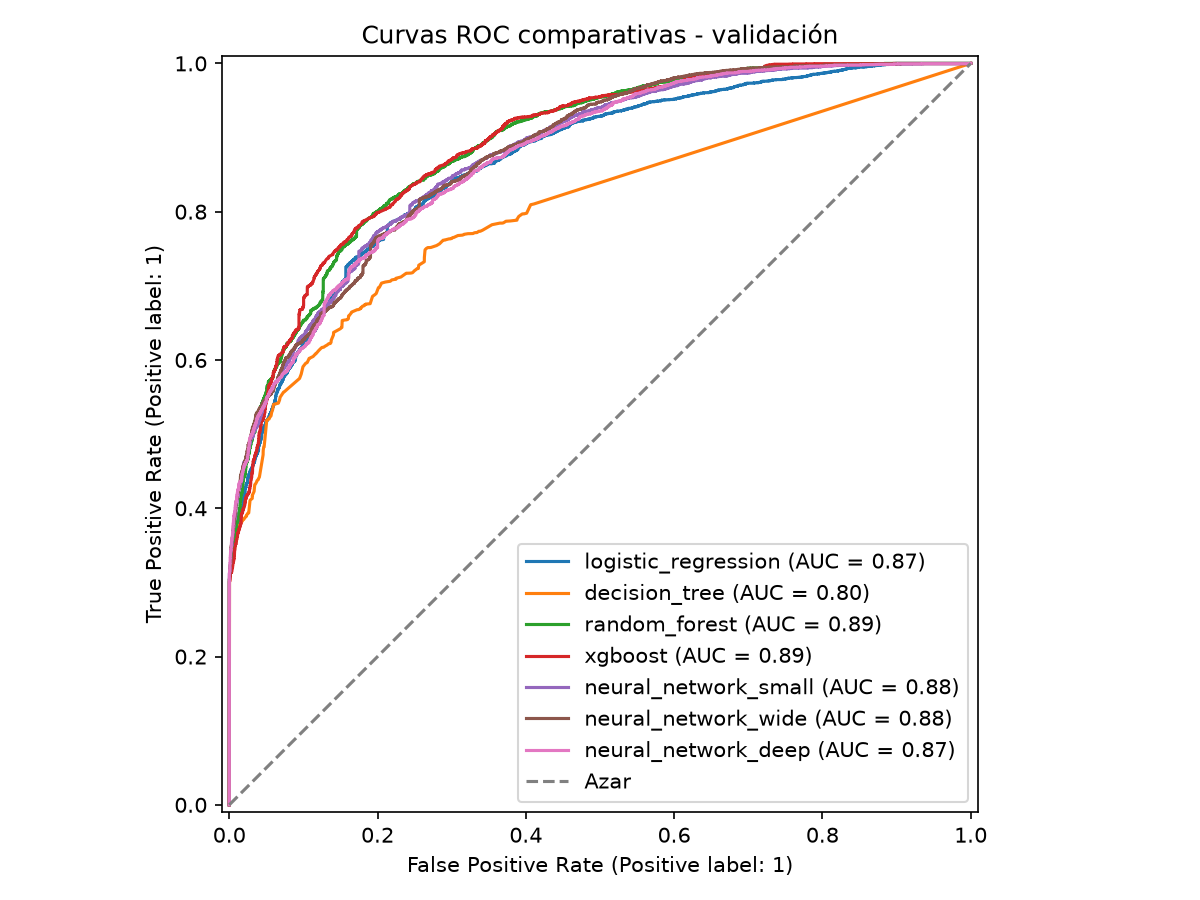

In [18]:
from IPython.display import Image, display

comparison_plot = project_root / 'artifacts' / 'model_optimization' / 'comparative_roc.png'
display(Image(filename=str(comparison_plot), width=1000))

## Curvas ROC por modelo

A continuación se muestran las curvas ROC individuales para cada modelo comparado. La zona superior izquierda y la mayor superficie bajo la curva indican mejor capacidad discriminativa del modelo ante la cancelación.

--- optimized_decision_tree_roc_curve.png ---


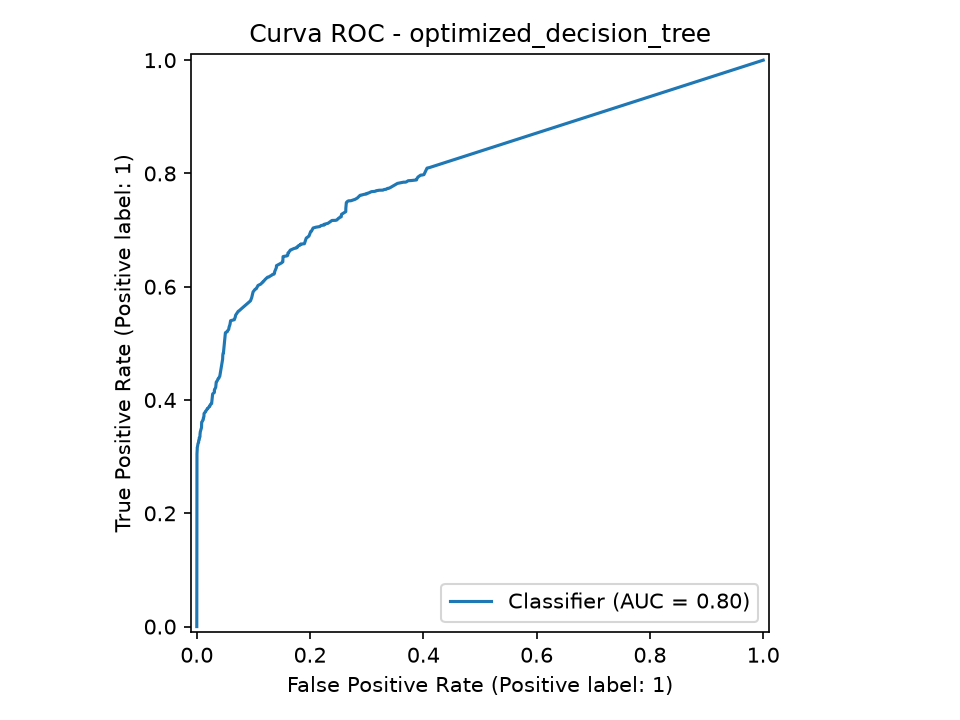

--- optimized_logistic_regression_roc_curve.png ---


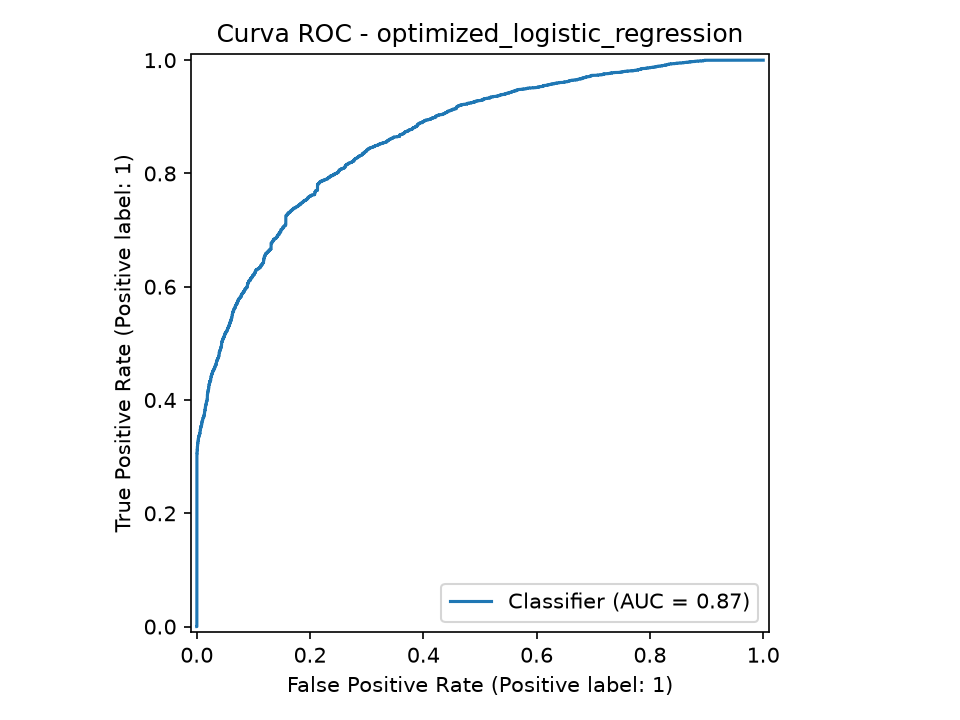

--- optimized_neural_network_deep_roc_curve.png ---


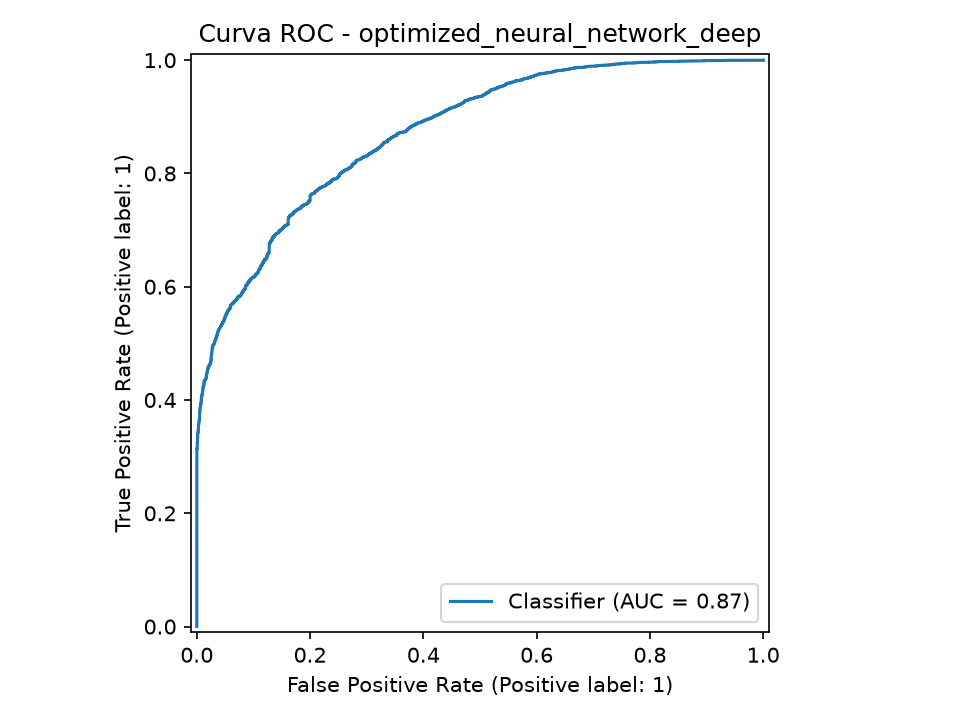

--- optimized_neural_network_small_roc_curve.png ---


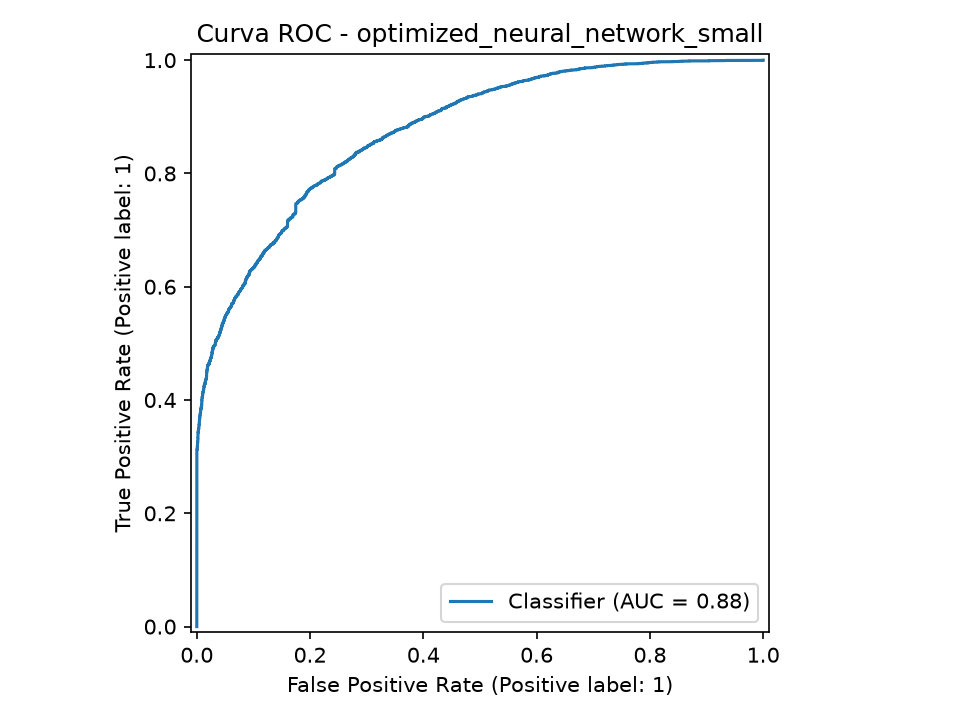

--- optimized_neural_network_wide_roc_curve.png ---


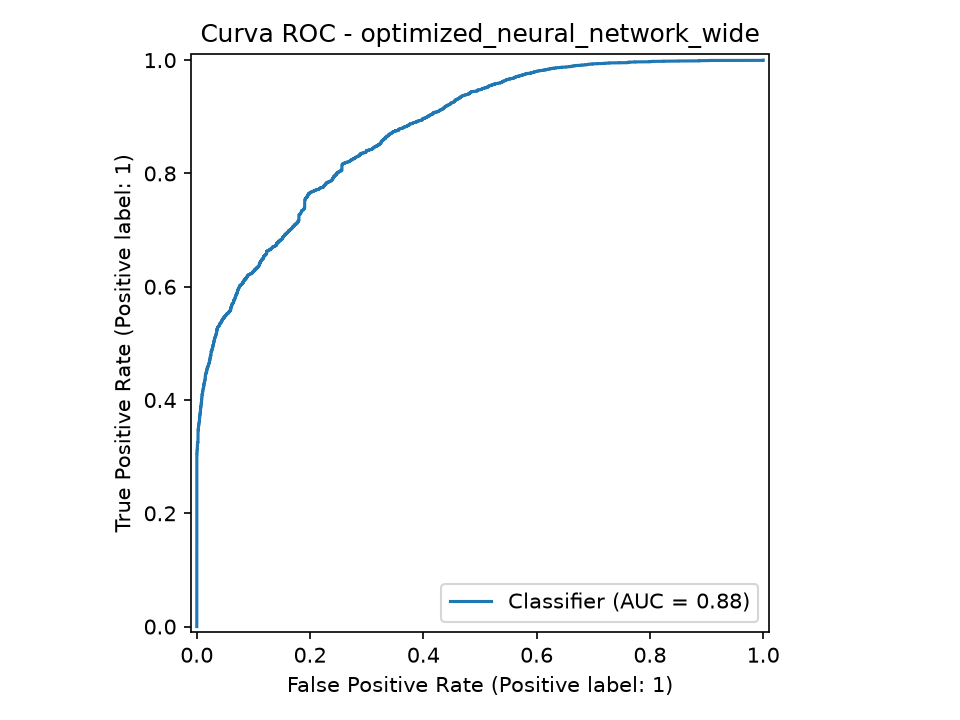

--- optimized_random_forest_roc_curve.png ---


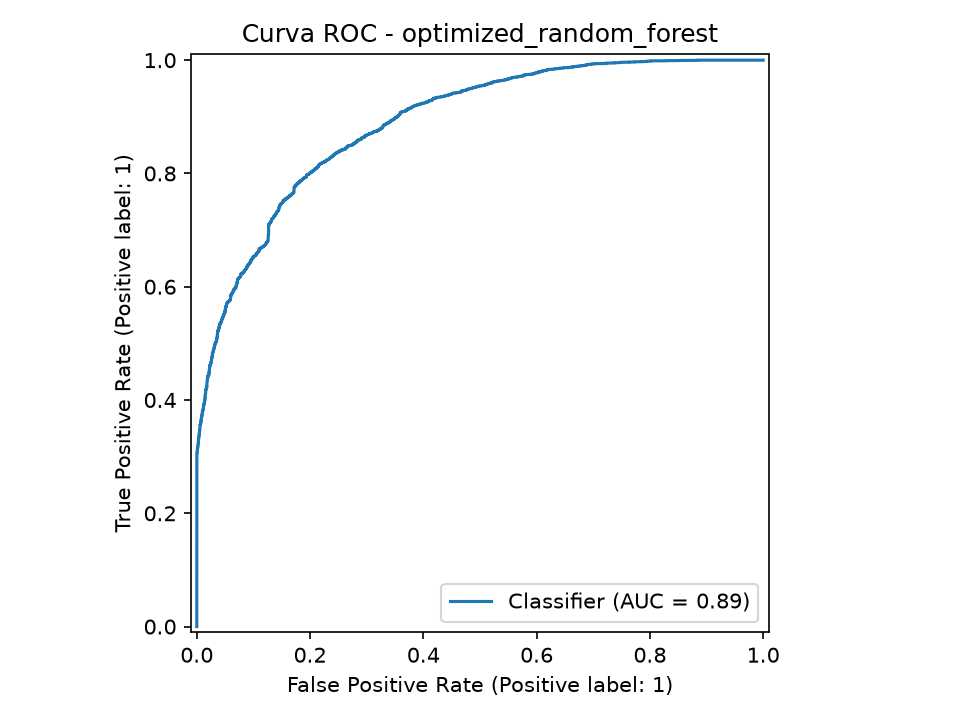

--- optimized_xgboost_roc_curve.png ---


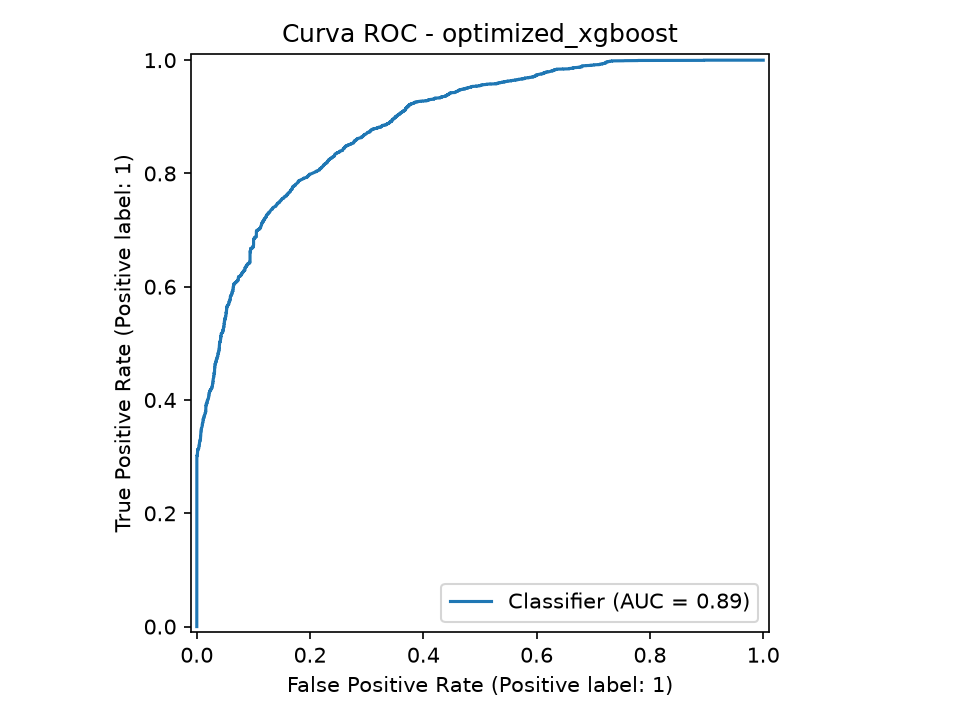

In [19]:
from IPython.display import display, Image

roc_files = sorted((project_root / 'artifacts' / 'model_optimization').glob('*_roc_curve.png'))
for path in roc_files:
    print(f'--- {path.name} ---')
    display(Image(filename=str(path), width=700))

## Decisión final

El modelo ganador fue XGBoost, con los siguientes resultados en validación:

- F1: 0,7575
- ROC-AUC: 0,8892
- Recall: 0,7860
- Precision: 0,7310
- Accuracy: 0,8077

Estos valores, junto con la curva ROC observada, justifican la elección del modelo final para la predicción de cancelaciones en la validación temporal final.